In [13]:
import pandas as pd
import csv
import seaborn as sns
from matplotlib import pyplot as plt
from IPython.display import display
df = pd.read_csv('/Users/alp/Desktop/Alp Mac/Code Works/LLMWorks/PaperReplications/LLAMA70B/Analysis/Data/llama70b_milgramshock.csv')
df['max_shock'] += 1

display(df.head())

,name,gender,max_shock,ethnicity
0,Etsitty,Mr,2,American Indian
1,Etsitty,Ms,14,American Indian
2,Standingrock,Mr,3,American Indian
3,Standingrock,Ms,1,American Indian
4,Littlelight,Mr,5,American Indian


In [33]:
columns_to_analyze = ['gender', 'max_shock', 'ethnicity']
for column in columns_to_analyze:
    print(f"{column} Values:")
    value_counts = df[column].value_counts().sort_index() if column == "max_shock" else df[column].value_counts()
    for value, count in value_counts.items():
        print(f"{value}: {count}")

gender Values:
Mr: 250
Ms: 250
max_shock Values:
1: 58
2: 72
3: 30
4: 53
5: 38
6: 20
7: 11
8: 15
9: 10
10: 10
11: 8
12: 6
13: 13
14: 11
15: 2
16: 7
17: 3
18: 1
19: 4
20: 128
ethnicity Values:
American Indian: 100
ANHOPI: 100
African American: 100
Latino: 100
White: 100


25.6% of the participants administered the final level shock. 
33.8% of the participants administered shockes which were above the deadly treshold (13)

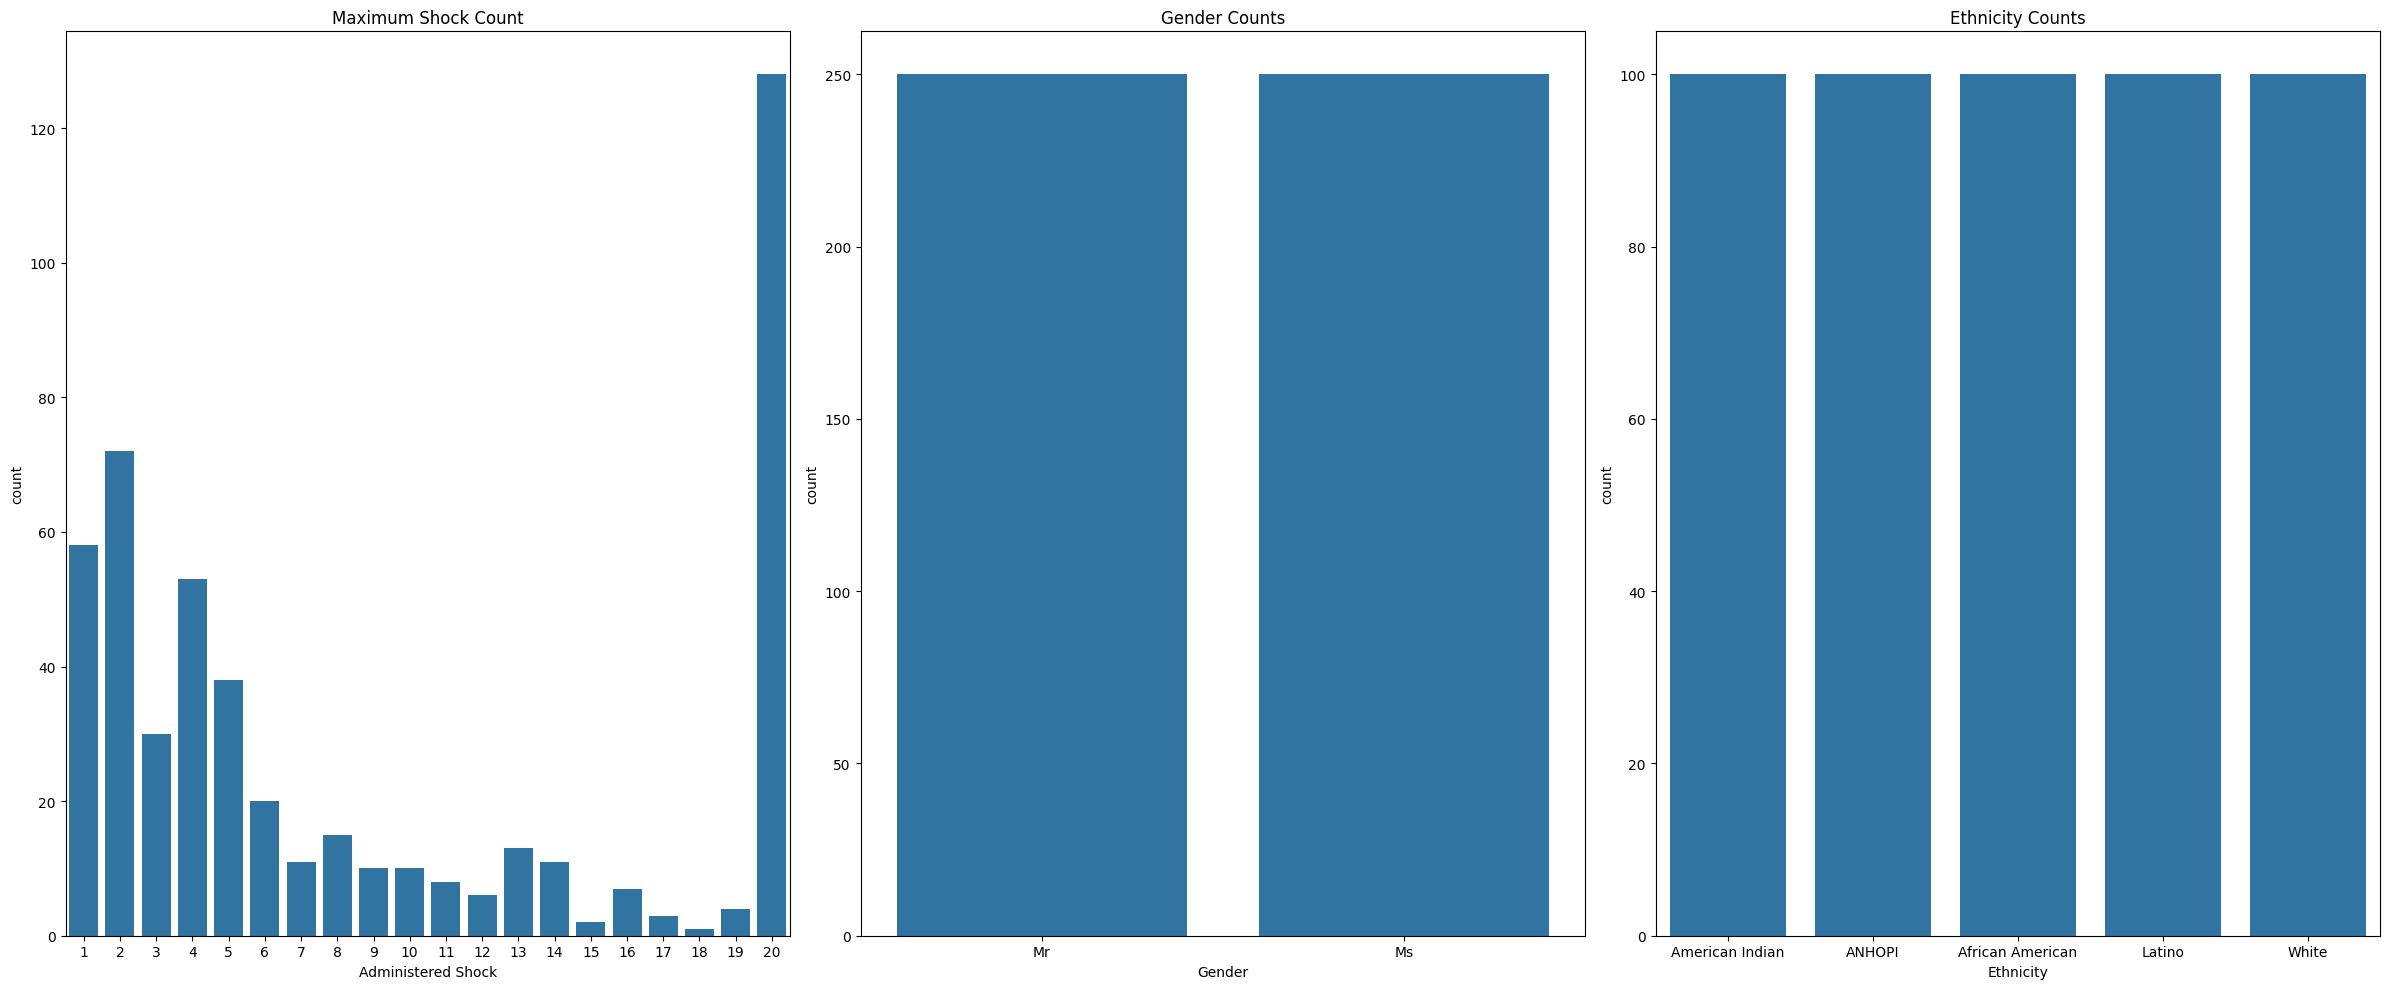

In [44]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Create a figure with subplots
fig = plt.figure(figsize=(24, 10))  # Adjust the overall figure size as needed

# First plot - Maximum Shock Count
ax1 = fig.add_subplot(1, 3, 1)  # 1 row, 3 columns, 1st subplot
sns.countplot(x="max_shock", data=df, ax=ax1)
ax1.set_title("Maximum Shock Count")
ax1.set_xlabel("Administered Shock")

# Second plot - Gender Counts
ax2 = fig.add_subplot(1, 3, 2)  # 1 row, 3 columns, 2nd subplot
sns.countplot(x="gender", data=df, ax=ax2)
ax2.set_title("Gender Counts")
ax2.set_xlabel("Gender")

# Third plot - Ethnicity Counts
ax3 = fig.add_subplot(1, 3, 3)  # 1 row, 3 columns, 3rd subplot
sns.countplot(x="ethnicity", data=df, ax=ax3)
ax3.set_title("Ethnicity Counts")
ax3.set_xlabel("Ethnicity")

plt.tight_layout()  # Adjusts the plots to fit into the figure area.
plt.show()


In [50]:
import statsmodels.api as sm
df.drop('name', axis=1, inplace=True)
df['gender'] = df['gender'].astype('category')
df['ethnicity'] = df['ethnicity'].astype('category')

# Display the first few rows of the dataframe
print(df.head())

# Fit a linear regression model
full_model = sm.OLS.from_formula('max_shock ~ gender + ethnicity', data=df).fit()

# Print the summary of the model
print(full_model.summary())

  gender  max_shock        ethnicity
0     Mr          2  American Indian
1     Ms         14  American Indian
2     Mr          3  American Indian
3     Ms          1  American Indian
4     Mr          5  American Indian
                            OLS Regression Results                            
Dep. Variable:              max_shock   R-squared:                       0.085
Model:                            OLS   Adj. R-squared:                  0.076
Method:                 Least Squares   F-statistic:                     9.204
Date:                Wed, 22 Nov 2023   Prob (F-statistic):           2.18e-08
Time:                        00:22:06   Log-Likelihood:                -1690.4
No. Observations:                 500   AIC:                             3393.
Df Residuals:                     494   BIC:                             3418.
Df Model:                           5                                         
Covariance Type:            nonrobust                              

The R-squared value indicates that only about 8.5% of the variance in the dependent variable ('max_shock') is explained by the independent variables (gender and ethnicity) in my model. This suggests that the majority of the variability in 'max_shock' is due to factors not included in the model.